<sub>`Data Science | Operations Research (OR)`</sub>

# **WORKFORCE ALLOCATION OPTIMIZATION & SENSITIVITY ANALYSIS**

---

#### **Optimasi Biaya dan Alokasi Tenaga Kerja di Bawah Ketidakpastian Demand: Pendekatan Mathematical Programming dan Analisis Sensitivitas pada Sistem Bike-Sharing Seoul**

## **`[1]` Import Library**

In [1]:
# ==================================================
# 1. IMPORT LIBRARY
# ==================================================
#---------------------------------------------------
# 1.1 Instalasi Library yang Diperlukan
#---------------------------------------------------
!pip install ucimlrepo pulp -q

In [2]:
#---------------------------------------------------
# 1.2 Import Semua Library
#---------------------------------------------------
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

warnings.filterwarnings('ignore')

## **`[2]` Konfigurasi dan Reproducibility**

In [3]:
# ==================================================
# 2. KONFIGURASI DAN REPRODUCIBILITY
# ==================================================
#---------------------------------------------------
# 2.1 Gaya Visualisasi dan Opsi Tampilan
#---------------------------------------------------
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [4]:
#---------------------------------------------------
# 2.2 Path Dataset
#---------------------------------------------------
# Path file lokal, dipakai hanya sebagai fallback jika ucimlrepo gagal diakses
DATA_PATH_FALLBACK = 'SeoulBikeData.csv'

## **`[3]` Load Dataset**

In [5]:
# ==================================================
# 3. LOAD DATASET
# ==================================================
#---------------------------------------------------
# 3.1 Fetch Dataset dari UCI Repository (dengan fallback lokal)
#---------------------------------------------------
try:
    from ucimlrepo import fetch_ucirepo

    # Fetch dataset
    seoul_bike_sharing_demand = fetch_ucirepo(id=560)

    # Data sebagai pandas DataFrame
    X = seoul_bike_sharing_demand.data.features
    y = seoul_bike_sharing_demand.data.targets

    # Metadata
    print(seoul_bike_sharing_demand.metadata)

    # Informasi variabel
    print(seoul_bike_sharing_demand.variables)

    df_raw = pd.concat([X, y], axis=1)
    print('\nDataset berhasil dimuat melalui ucimlrepo.')
except Exception as e:
    # Fallback jika koneksi ke UCI API tidak tersedia di lingkungan eksekusi ini
    print(f'Gagal memuat via ucimlrepo: {e}')
    print('Menggunakan file lokal sebagai cadangan (sumber data sama, UCI id 560).')
    df_raw = pd.read_csv(DATA_PATH_FALLBACK, encoding='latin1')

{'uci_id': 560, 'name': 'Seoul Bike Sharing Demand', 'repository_url': 'https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand', 'data_url': 'https://archive.ics.uci.edu/static/public/560/data.csv', 'abstract': 'The dataset contains count of public bicycles rented per hour in the Seoul Bike Sharing System, with corresponding weather data and holiday information', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 8760, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Functioning Day'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Mon Feb 05 2024', 'dataset_doi': '10.24432/C5F62R', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'Currently Rental bikes are introduced in many urban cities for the enhancement of mobility comfort. It is important to make the rental bike available and a

In [6]:
#---------------------------------------------------
# 3.2 Standardisasi Nama Kolom
#---------------------------------------------------
def clean_colname(col):
    col = re.sub(r'\(.*?\)', '', col)
    col = col.strip().lower()
    col = re.sub(r'[^a-z0-9]+', '_', col)
    return col.strip('_')

df_raw.columns = [clean_colname(c) for c in df_raw.columns]
print('Jumlah baris, kolom:', df_raw.shape)
print('Kolom:', df_raw.columns.tolist())

Jumlah baris, kolom: (8760, 14)
Kolom: ['date', 'rented_bike_count', 'hour', 'temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation', 'rainfall', 'snowfall', 'seasons', 'holiday', 'functioning_day']


## **`[4]` Data Overview**

In [7]:
# ==================================================
# 4. DATA OVERVIEW
# ==================================================
#---------------------------------------------------
# 4.1 Lima Baris Pertama dan Tipe Data
#---------------------------------------------------
display(df_raw.head())
df_raw.info()

,date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,seasons,holiday,functioning_day
0,1/12/2017,254,0,-5.20,37,2.20,2000,-17.60,0.00,0.00,0.00,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.50,38,0.80,2000,-17.60,0.00,0.00,0.00,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.00,39,1.00,2000,-17.70,0.00,0.00,0.00,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.20,40,0.90,2000,-17.60,0.00,0.00,0.00,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.00,36,2.30,2000,-18.60,0.00,0.00,0.00,Winter,No Holiday,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   8760 non-null   object 
 1   rented_bike_count      8760 non-null   int64  
 2   hour                   8760 non-null   int64  
 3   temperature            8760 non-null   float64
 4   humidity               8760 non-null   int64  
 5   wind_speed             8760 non-null   float64
 6   visibility             8760 non-null   int64  
 7   dew_point_temperature  8760 non-null   float64
 8   solar_radiation        8760 non-null   float64
 9   rainfall               8760 non-null   float64
 10  snowfall               8760 non-null   float64
 11  seasons                8760 non-null   object 
 12  holiday                8760 non-null   object 
 13  functioning_day        8760 non-null   object 
dtypes: float64(6), int64(4), object(4)
memory usage: 958.3+ 

In [8]:
#---------------------------------------------------
# 4.2 Statistik Deskriptif dan Kategori
#---------------------------------------------------
display(df_raw.describe())
for col in ['seasons', 'holiday', 'functioning_day']:
    print(col, ':', df_raw[col].unique())

,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall
count,"8,760.00","8,760.00","8,760.00","8,760.00","8,760.00","8,760.00","8,760.00","8,760.00","8,760.00","8,760.00"
mean,704.60,11.50,12.88,58.23,1.72,"1,436.83",4.07,0.57,0.15,0.08
std,645.00,6.92,11.94,20.36,1.04,608.30,13.06,0.87,1.13,0.44
min,0.00,0.00,-17.80,0.00,0.00,27.00,-30.60,0.00,0.00,0.00
25%,191.00,5.75,3.50,42.00,0.90,940.00,-4.70,0.00,0.00,0.00
50%,504.50,11.50,13.70,57.00,1.50,"1,698.00",5.10,0.01,0.00,0.00
75%,"1,065.25",17.25,22.50,74.00,2.30,"2,000.00",14.80,0.93,0.00,0.00
max,"3,556.00",23.00,39.40,98.00,7.40,"2,000.00",27.20,3.52,35.00,8.80


seasons : ['Winter' 'Spring' 'Summer' 'Autumn']
holiday : ['No Holiday' 'Holiday']
functioning_day : ['Yes' 'No']


Dari output `describe()`, kolom **rented_bike_count** memiliki rentang yang sangat lebar (minimum mendekati 0, maksimum di atas 3.000) dengan rata-rata jauh di atas mediannya, mengindikasikan distribusi yang menjulur ke kanan. Tiga kolom kategorikal (`seasons`, `holiday`, `functioning_day`) masing-masing punya 4, 2, dan 2 kategori, sesuai dengan dokumentasi dataset. Detail distribusi ini diperiksa lebih lanjut pada bagian EDA.

## **`[5]` Data Quality Assessment**

In [9]:
# ==================================================
# 5. DATA QUALITY ASSESSMENT
# ==================================================
#---------------------------------------------------
# 5.1 Missing Value dan Duplikasi
#---------------------------------------------------
print('Missing value per kolom:')
print(df_raw.isnull().sum())
print('\nJumlah baris duplikat:', df_raw.duplicated().sum())

Missing value per kolom:
date                     0
rented_bike_count        0
hour                     0
temperature              0
humidity                 0
wind_speed               0
visibility               0
dew_point_temperature    0
solar_radiation          0
rainfall                 0
snowfall                 0
seasons                  0
holiday                  0
functioning_day          0
dtype: int64

Jumlah baris duplikat: 0


In [10]:
#---------------------------------------------------
# 5.2 Distribusi Functioning Day
#---------------------------------------------------
print(df_raw['functioning_day'].value_counts())
print()
print('Statistik rented_bike_count saat functioning_day == No:')
print(df_raw.loc[df_raw['functioning_day'] == 'No', 'rented_bike_count'].describe())

functioning_day
Yes    8465
No      295
Name: count, dtype: int64

Statistik rented_bike_count saat functioning_day == No:
count   295.00
mean      0.00
std       0.00
min       0.00
25%       0.00
50%       0.00
75%       0.00
max       0.00
Name: rented_bike_count, dtype: float64


Tidak ditemukan missing value maupun baris duplikat di seluruh kolom. Bagian yang perlu diperhatikan ada pada **functioning_day**, karena terdapat 295 baris berstatus "No", dan keseluruhan baris tersebut memiliki rented_bike_count tepat 0. Nilai nol ini bukan demand riil yang rendah, melainkan penanda bahwa layanan sedang tidak beroperasi pada jam tersebut. Jika baris ini tidak dikeluarkan, profil demand yang dipakai sebagai basis kebutuhan staf akan bias ke bawah, sehingga harus difilter pada tahap cleaning.

## **`[6]` Data Cleaning**

Dua langkah cleaning yang dilakukan disini adalah parsing tanggal dan pengeluaran baris non-operasional. Tidak dilakukan scaling, encoding, atau train-test split karena notebook ini tidak membangun model prediktif.

In [11]:
# ==================================================
# 6. DATA CLEANING
# ==================================================
#---------------------------------------------------
# 6.1 Parsing Tanggal
#---------------------------------------------------
df_raw['date'] = pd.to_datetime(df_raw['date'], format='%d/%m/%Y')
print('Rentang tanggal:', df_raw['date'].min(), '-', df_raw['date'].max())

Rentang tanggal: 2017-12-01 00:00:00 - 2018-11-30 00:00:00


In [12]:
#---------------------------------------------------
# 6.2 Filter Hari Non-Operasional
#---------------------------------------------------
# Baris functioning_day == 'No' dikeluarkan karena bukan demand riil, melainkan layanan tutup
df = df_raw[df_raw['functioning_day'] == 'Yes'].copy()
print('Shape sebelum filter :', df_raw.shape)
print('Shape sesudah filter :', df.shape)
print('Baris yang dikeluarkan:', df_raw.shape[0] - df.shape[0])

Shape sebelum filter : (8760, 14)
Shape sesudah filter : (8465, 14)
Baris yang dikeluarkan: 295


Jumlah baris berkurang dari 8.760 menjadi 8.465 setelah baris non-operasional dikeluarkan, persis sesuai 295 baris yang teridentifikasi pada Data Quality Assessment. Dataset hasil cleaning ini (`df`) dipakai sebagai basis seluruh perhitungan pada bagian selanjutnya.

## **`[7]` Exploratory Data Analysis**

EDA dilakukan untuk memahami karakter demand sebagai dasar penentuan profil kebutuhan staf, bukan untuk eksplorasi umum. Setiap visualisasi dipilih karena akan dipakai langsung pada bagian formulasi model atau sensitivity analysis.

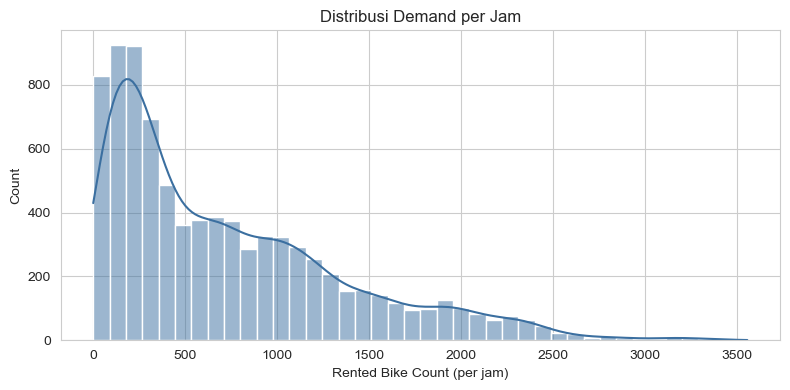

count   8,465.00
mean      729.16
std       642.35
min         2.00
25%       214.00
50%       542.00
75%     1,084.00
max     3,556.00
Name: rented_bike_count, dtype: float64
Skewness: 1.14


In [13]:
# ==================================================
# 7. EXPLORATORY DATA ANALYSIS
# ==================================================
#---------------------------------------------------
# 7.1 Distribusi Rented Bike Count
#---------------------------------------------------
_original_subplots = plt.subplots
saved_figures = []

def subplots_hook(*args, **kwargs):
    fig, ax = _original_subplots(*args, **kwargs)
    saved_figures.append(fig)
    return fig, ax

plt.subplots = subplots_hook

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['rented_bike_count'], bins=40, kde=True, ax=ax, color='#3b6fa0')
ax.set_xlabel('Rented Bike Count (per jam)')
ax.set_title('Distribusi Demand per Jam')
plt.tight_layout()
plt.show()

print(df['rented_bike_count'].describe())
print('Skewness:', df['rented_bike_count'].skew().round(2))

Distribusi demand menjulur ke kanan dengan skewness sekitar **1,14**, rata-rata 729 unit per jam namun median hanya di kisaran 542. Selisih ini berarti sebagian kecil jam dengan demand sangat tinggi menarik rata-rata ke atas, sehingga representative day yang dipakai untuk model perlu memakai rata-rata per jam (bukan median) supaya jam-jam sibuk tetap tertangkap dalam kebutuhan staf.

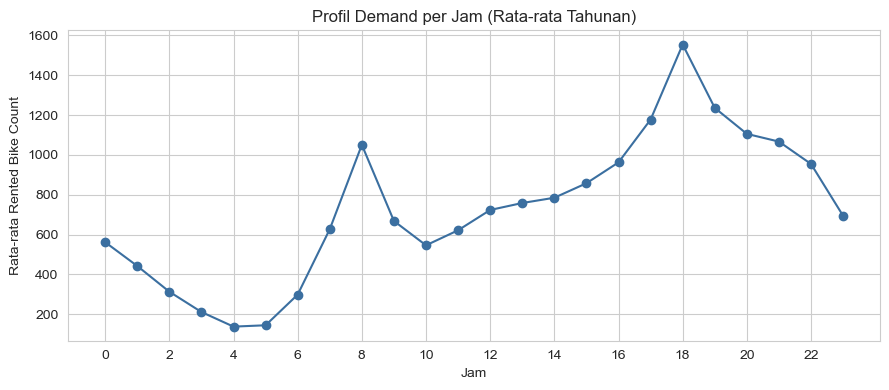

hour
0      561.50
1      441.90
2      312.80
3      210.80
4      137.50
5      144.20
6      298.20
7      626.60
8    1,050.20
9      667.90
10     545.80
11     621.30
12     723.20
13     758.20
14     784.60
15     857.40
16     962.30
17   1,177.20
18   1,554.00
19   1,235.80
20   1,105.30
21   1,066.50
22     954.20
23     693.90
Name: rented_bike_count, dtype: float64


In [14]:
#---------------------------------------------------
# 7.2 Profil Demand per Jam (Seluruh Data)
#---------------------------------------------------
hourly_profile = df.groupby('hour')['rented_bike_count'].mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hourly_profile.index, hourly_profile.values, marker='o', color='#3b6fa0')
ax.set_xlabel('Jam')
ax.set_ylabel('Rata-rata Rented Bike Count')
ax.set_title('Profil Demand per Jam (Rata-rata Tahunan)')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

print(hourly_profile.round(1))

Pola demand per jam terlihat **bimodal**, dengan puncak pertama di sekitar jam 08:00 (rata-rata 1.050 unit) dan puncak kedua yang lebih tinggi di jam 18:00 (rata-rata 1.554 unit), khas pola commuting. Sementara titik terendah ada di jam 04:00 (rata-rata 138 unit). Pola dua puncak inilah yang nantinya membentuk kebutuhan staf paling tinggi pada shift Pagi menjelang siang dan shift Siang menjelang malam, bukan distribusi yang rata di sepanjang hari.

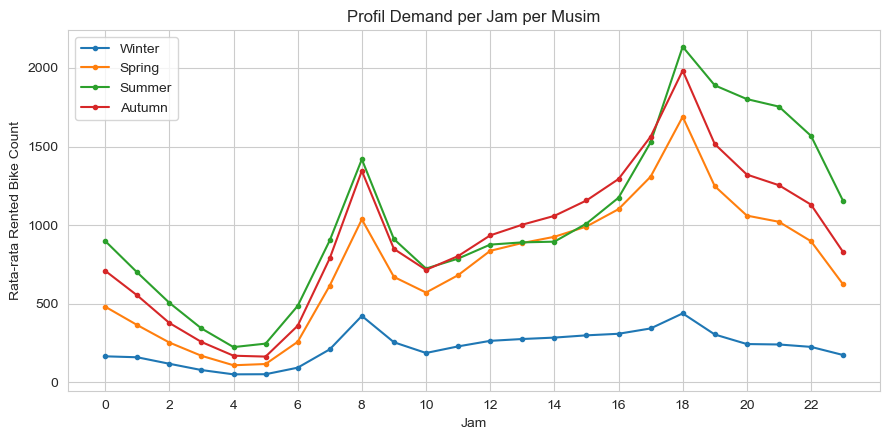

seasons
Winter     225.50
Spring     746.30
Autumn     924.10
Summer   1,034.10
Name: rented_bike_count, dtype: float64


In [15]:
#---------------------------------------------------
# 7.3 Profil Demand per Jam per Musim
#---------------------------------------------------
hourly_season = df.groupby(['seasons', 'hour'])['rented_bike_count'].mean().unstack(0)
fig, ax = plt.subplots(figsize=(9, 4.5))
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    ax.plot(hourly_season.index, hourly_season[season], marker='o', markersize=3, label=season)
ax.set_xlabel('Jam')
ax.set_ylabel('Rata-rata Rented Bike Count')
ax.set_title('Profil Demand per Jam per Musim')
ax.legend()
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

print(df.groupby('seasons')['rented_bike_count'].mean().round(1).sort_values())

Dari angka rata-rata per musim, **Winter** berada paling rendah (226 unit per jam) sementara **Summer** paling tinggi (1.034 unit per jam), rasio sekitar **4,6 kali**, dengan Spring (746) dan Autumn (924) berada di antaranya. Bentuk pola bimodalnya tetap konsisten di semua musim, hanya lonjakannya yang berbeda jauh. Perbedaan ini akan dipakai sebagai skenario empiris pada sensitivity analysis, karena mencerminkan pergeseran demand yang benar-benar terjadi.

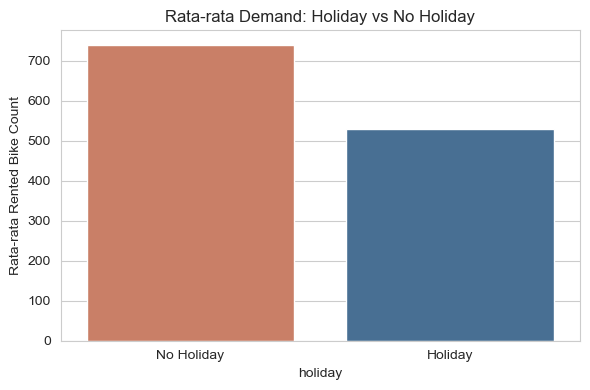

holiday
Holiday      529.20
No Holiday   739.30
Name: rented_bike_count, dtype: float64


In [16]:
#---------------------------------------------------
# 7.4 Demand: Holiday vs No Holiday
#---------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df, x='holiday', y='rented_bike_count', ax=ax, palette=['#d97757', '#3b6fa0'], errorbar=None)
ax.set_ylabel('Rata-rata Rented Bike Count')
ax.set_title('Rata-rata Demand: Holiday vs No Holiday')
plt.tight_layout()
plt.show()

print(df.groupby('holiday')['rented_bike_count'].mean().round(1))

Rata-rata demand pada hari libur berada di 529 unit per jam, lebih rendah dibanding 739 unit pada hari biasa.

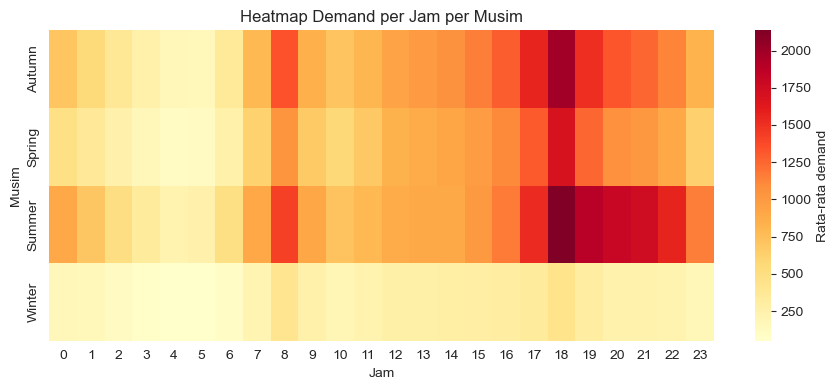

In [17]:
#---------------------------------------------------
# 7.5 Heatmap Jam x Musim
#---------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(hourly_season.T, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Rata-rata demand'}, ax=ax)
ax.set_xlabel('Jam')
ax.set_ylabel('Musim')
ax.set_title('Heatmap Demand per Jam per Musim')
plt.tight_layout()
plt.show()

Heatmap ini memperjelas titik kritis yang sama persis di setiap musim, yaitu sekitar jam 07.00 sampai 09.00 dan 17.00 sampai 19.00, namun dengan intensitas warna yang jauh lebih gelap pada Summer dibanding Winter pada jam yang sama. Ini menjadi dasar penentuan jam-jam mana yang paling membutuhkan kapasitas staf ekstra, dan menjadi acuan penetapan shift pada Section 8.

In [18]:
#---------------------------------------------------
# 7.6 Pemeriksaan Tambahan: Weekday vs Weekend
#---------------------------------------------------
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6])
print(df.groupby('is_weekend')['rented_bike_count'].mean().round(1))

is_weekend
False   748.10
True    682.40
Name: rented_bike_count, dtype: float64


Selisih rata-rata demand antara hari kerja (748) dan akhir pekan (682) jauh lebih kecil dibanding selisih antarmusim maupun holiday. Karena sinyalnya tergolong tipis, dimensi weekday/weekend tidak dijadikan sumbu sensitivity analysis utama, dan skenario empiris difokuskan pada musim serta status holiday yang polanya lebih tegas.

## **`[8]` Definisi Parameter Optimasi**

Dataset Seoul Bike Sharing tidak memuat data biaya tenaga kerja, kapasitas staf, atau definisi shift operasional. Seluruh parameter pada bagian ini adalah **asumsi** yang ditetapkan secara masuk akal, bukan hasil estimasi dari data.

In [19]:
# ==================================================
# 8. DEFINISI PARAMETER OPTIMASI
# ==================================================
#---------------------------------------------------
# 8.1 Parameter Kapasitas dan Pola Shift
#---------------------------------------------------
# Misal satu staf menangani 50 unit transaksi sewa per jam (mencakup monitoring,
# rebalancing ringan, dan layanan pelanggan).
CAPACITY_PER_WORKER = 50

# Pola 3 shift dengan durasi tidak seragam, menyesuaikan kebutuhan operasional
SHIFTS = {
    'Pagi':  list(range(0, 10)),   # 00:00 - 10:00 (10 jam)
    'Siang': list(range(10, 17)),  # 10:00 - 17:00 (7 jam)
    'Malam': list(range(17, 24)),  # 17:00 - 24:00 (7 jam)
}
SHIFT_LENGTHS = {s: len(hrs) for s, hrs in SHIFTS.items()}
print('Durasi tiap shift (jam):', SHIFT_LENGTHS)

Durasi tiap shift (jam): {'Pagi': 10, 'Siang': 7, 'Malam': 7}


In [20]:
#---------------------------------------------------
# 8.2 Parameter Biaya Tenaga Kerja
#---------------------------------------------------
# Upah reguler per jam
WAGE_REGULAR_PER_HOUR = 25000  # dalam Rupiah

# Biaya 1 staf untuk 1 shift penuh, mengikuti durasi masing-masing shift (tidak seragam)
COST_REGULAR_PER_SHIFT = {s: WAGE_REGULAR_PER_HOUR * SHIFT_LENGTHS[s] for s in SHIFTS}

# Misal staf tambahan dibayar 1.5 kali tarif reguler per jam, bukan dari dataset
PREMIUM_MULTIPLIER = 1.5
COST_STAF_TAMBAHAN_PER_HOUR = WAGE_REGULAR_PER_HOUR * PREMIUM_MULTIPLIER

print('Biaya staf reguler per shift  :', {s: f"Rp{v:,.0f}" for s, v in COST_REGULAR_PER_SHIFT.items()})
print('Biaya staf tambahan per jam per staf : Rp', f'{COST_STAF_TAMBAHAN_PER_HOUR:,.0f}')

Biaya staf reguler per shift  : {'Pagi': 'Rp250,000', 'Siang': 'Rp175,000', 'Malam': 'Rp175,000'}
Biaya staf tambahan per jam per staf : Rp 37,500


In [21]:
#---------------------------------------------------
# 8.3 Parameter Batas Kapasitas dan Target Service Level
#---------------------------------------------------
# Misal batas anggaran/HR membatasi maksimum 20 staf reguler per shift
MAX_WORKERS_PER_SHIFT = 20

# Target service level baseline 100% (seluruh kebutuhan staf per jam wajib terpenuhi)
SERVICE_LEVEL_BASELINE = 1.0

## **`[9]` Derivasi Kebutuhan Staf**

Demand (rented_bike_count) dijadikan kebutuhan staf per jam melalui pembagian dengan kapasitas per staf lalu dibulatkan ke atas.

In [22]:
# ==================================================
# 9. DERIVASI KEBUTUHAN STAF
# ==================================================
#---------------------------------------------------
# 9.1 Profil Demand Baseline
#---------------------------------------------------
baseline_demand = df.groupby('hour')['rented_bike_count'].mean()
print(baseline_demand.round(1))

hour
0      561.50
1      441.90
2      312.80
3      210.80
4      137.50
5      144.20
6      298.20
7      626.60
8    1,050.20
9      667.90
10     545.80
11     621.30
12     723.20
13     758.20
14     784.60
15     857.40
16     962.30
17   1,177.20
18   1,554.00
19   1,235.80
20   1,105.30
21   1,066.50
22     954.20
23     693.90
Name: rented_bike_count, dtype: float64


In [23]:
#---------------------------------------------------
# 9.2 Fungsi Translasi Demand ke Required Staff
#---------------------------------------------------
def required_staff(demand_series, capacity=CAPACITY_PER_WORKER):
    # Pembulatan ke atas
    return {h: int(np.ceil(demand_series[h] / capacity)) for h in range(24)}

R_baseline = required_staff(baseline_demand)
print('Kebutuhan staf per jam (baseline):')
print(R_baseline)

Kebutuhan staf per jam (baseline):
{0: 12, 1: 9, 2: 7, 3: 5, 4: 3, 5: 3, 6: 6, 7: 13, 8: 22, 9: 14, 10: 11, 11: 13, 12: 15, 13: 16, 14: 16, 15: 18, 16: 20, 17: 24, 18: 32, 19: 25, 20: 23, 21: 22, 22: 20, 23: 14}


Kebutuhan staf hasil translasi berkisar dari 3 orang pada jam paling sepi (04:00-05:00) hingga 32 orang pada jam paling sibuk (18:00). Rentang ini langsung menjadi parameter sisi kanan (RHS) pada constraint coverage di model optimasi, sehingga jam-jam dengan kebutuhan tinggi seperti ini yang akan menentukan apakah shift terkait perlu staf reguler lebih banyak atau cukup ditutup dengan staf tambahan.

## **`[10]` Formulasi dan Implementasi Mixed-Integer Programming (MIP)**

**Formulasi matematis**

Model ini adalah varian shift scheduling set-covering (gaya Dantzig) dengan tambahan variabel staf tambahan sebagai katup pengaman kapasitas.

Decision variable:
- $x_s \geq 0$, integer, jumlah staf reguler pada shift $s \in \{Pagi, Siang, Malam\}$
- $o_h \geq 0$, integer, jumlah staf tambahan pada jam $h \in \{0, 1, ..., 23\}$

Objective (minimasi total biaya):

$$\min \; \sum_{s} c^{reg}_{shift} \cdot x_s \; + \; \sum_{h=0}^{23} c^{ot}_{hour} \cdot o_h$$

Constraint coverage (kebutuhan staf per jam harus terpenuhi sesuai target service level $\alpha$):

$$\sum_{s \,:\, h \in S_s} x_s \; + \; o_h \; \geq \; R_h \cdot \alpha, \quad \forall h \in \{0, ..., 23\}$$

Constraint kapasitas shift:

$$x_s \leq X^{max}_{shift}, \quad \forall s$$

Durasi tiap shift tidak seragam (Pagi 10 jam, Siang dan Malam masing-masing 7 jam), sehingga $c^{reg}_{shift}$ dihitung sebagai upah per jam dikalikan durasi shift tersebut, bukan angka tetap yang sama untuk ketiga shift.

Variabel staf tambahan $o_h$ sengaja tidak dibatasi batas atas, sehingga model selalu feasible berapa pun lonjakan demand-nya. Konsekuensi dari kebutuhan staf yang melonjak bukan infeasibility, melainkan kenaikan biaya staf tambahan, yang menjadi materi utama sensitivity analysis pada Section 13.

In [24]:
# ==================================================
# 10. FORMULASI DAN IMPLEMENTASI MODEL OPTIMASI (MIP)
# ==================================================
#---------------------------------------------------
# 10.1 Fungsi Solve Model (Reusable)
#---------------------------------------------------
def solve_model(demand_series, capacity=CAPACITY_PER_WORKER, premium_mult=PREMIUM_MULTIPLIER,
                 max_per_shift=MAX_WORKERS_PER_SHIFT, service_level=SERVICE_LEVEL_BASELINE,
                 wage=WAGE_REGULAR_PER_HOUR, integer=True):
    R = required_staff(demand_series, capacity)
    # Biaya shift reguler mengikuti durasi masing-masing shift (Pagi, Siang, Malam tidak seragam)
    cost_reg_shift = {s: wage * len(SHIFTS[s]) for s in SHIFTS}
    cost_staf_tambahan_per_hour = wage * premium_mult
    cat = 'Integer' if integer else 'Continuous'

    # Definisi decision variable
    x = {s: pulp.LpVariable(f'x_{s}', lowBound=0, cat=cat) for s in SHIFTS}
    o = {h: pulp.LpVariable(f'o_{h}', lowBound=0, cat=cat) for h in range(24)}

    prob = pulp.LpProblem('Workforce_Shift_Scheduling', pulp.LpMinimize)

    # Fungsi objektif: total biaya reguler (mengikuti durasi shift) + total biaya staf tambahan
    prob += (pulp.lpSum(cost_reg_shift[s] * x[s] for s in SHIFTS)
             + pulp.lpSum(cost_staf_tambahan_per_hour * o[h] for h in range(24)))

    # Constraint coverage per jam
    coverage_constraints = {}
    for h in range(24):
        shifts_covering_h = [s for s, hrs in SHIFTS.items() if h in hrs]
        cname = f'coverage_h{h}'
        prob += (pulp.lpSum(x[s] for s in shifts_covering_h) + o[h] >= R[h] * service_level), cname
        coverage_constraints[h] = cname

    # Constraint batas kapasitas staf reguler per shift
    for s in SHIFTS:
        prob += x[s] <= max_per_shift, f'maxcap_{s}'

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    return {
        'status': pulp.LpStatus[prob.status],
        'total_cost': pulp.value(prob.objective),
        'x': {s: x[s].varValue for s in SHIFTS},
        'o': {h: o[h].varValue for h in range(24)},
        'R': R,
        'regular_cost': sum(cost_reg_shift[s] * x[s].varValue for s in SHIFTS),
        'cost_staf_tambahan': sum(cost_staf_tambahan_per_hour * o[h].varValue for h in range(24)),
        'prob': prob,
        'coverage_constraints': coverage_constraints,
    }

print('Fungsi solve_model() siap dipakai (biaya shift mengikuti durasi masing-masing, tidak seragam).')

Fungsi solve_model() siap dipakai (biaya shift mengikuti durasi masing-masing, tidak seragam).


## **`[11]` Validasi Solusi Baseline**

Model diselesaikan dengan profil demand baseline (rata-rata tahunan), lalu solusinya diperiksa dari sisi status solver, breakdown biaya, dan pemenuhan constraint sebelum dipakai sebagai acuan sensitivity analysis.

In [25]:
# ==================================================
# 11. VALIDASI SOLUSI BASELINE
# ==================================================
#---------------------------------------------------
# 11.1 Solve Baseline
#---------------------------------------------------
res_baseline = solve_model(baseline_demand)
print('Status solver   :', res_baseline['status'])
print('Total biaya     : Rp', f"{res_baseline['total_cost']:,.0f}")
print('Biaya reguler   : Rp', f"{res_baseline['regular_cost']:,.0f}")
print('Biaya staf tambahan    : Rp', f"{res_baseline['cost_staf_tambahan']:,.0f}")
print('Staf reguler    :', res_baseline['x'])

Status solver   : Optimal
Total biaya     : Rp 10,512,500
Biaya reguler   : Rp 7,625,000
Biaya staf tambahan    : Rp 2,887,500
Staf reguler    : {'Pagi': 6.0, 'Siang': 15.0, 'Malam': 20.0}


Solver mengembalikan status **Optimal** dengan total biaya Rp10.512.500 untuk satu hari representative, terdiri dari biaya reguler Rp7.625.000 dan biaya staf tambahan Rp2.887.500. Alokasi staf reguler condong ke shift Malam (20 orang, persis menyentuh batas maksimum 20), diikuti Siang (15 orang) dan Pagi (6 orang). Shift Malam yang menyentuh batas kapasitas mendorong sebagian kebutuhan jam sibuk, terutama jam 18.00 yang butuh 32 orang, ditutup lewat staf tambahan, bukan staf reguler tambahan.

In [26]:
#---------------------------------------------------
# 11.2 Validasi Constraint Coverage
#---------------------------------------------------
violations = []
for h in range(24):
    shifts_covering_h = [s for s, hrs in SHIFTS.items() if h in hrs]
    total_cover = sum(res_baseline['x'][s] for s in shifts_covering_h) + res_baseline['o'][h]
    if total_cover + 1e-6 < res_baseline['R'][h]:
        violations.append(h)
print('Jumlah jam yang melanggar constraint coverage:', len(violations))

Jumlah jam yang melanggar constraint coverage: 0


Tidak ada jam yang melanggar constraint coverage, sehingga solusi baseline ini valid dipakai sebagai titik acuan (anchor) untuk seluruh sensitivity analysis pada bagian berikutnya.

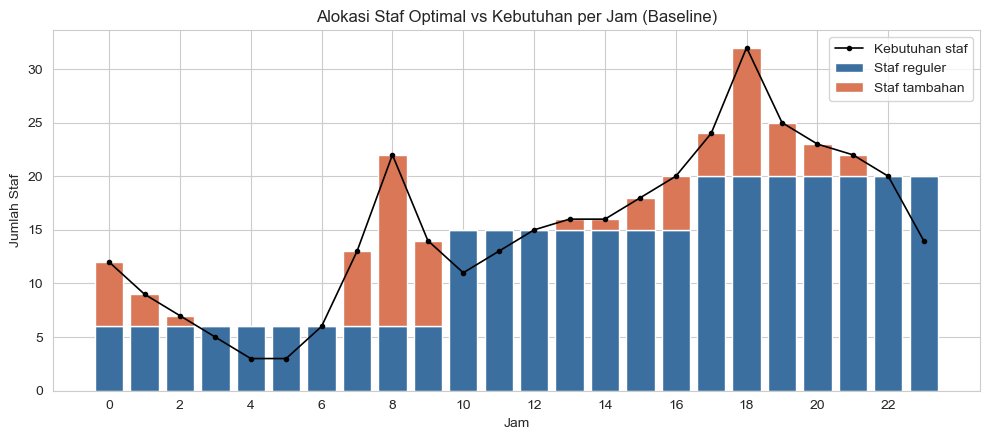

In [27]:
#---------------------------------------------------
# 11.3 Visualisasi Staffing vs Kebutuhan per Jam
#---------------------------------------------------
coverage_per_hour = []
for h in range(24):
    shifts_covering_h = [s for s, hrs in SHIFTS.items() if h in hrs]
    reg = sum(res_baseline['x'][s] for s in shifts_covering_h)
    coverage_per_hour.append({'hour': h, 'reguler': reg, 'staf_tambahan': res_baseline['o'][h],
                               'kebutuhan': res_baseline['R'][h]})
cov_df = pd.DataFrame(coverage_per_hour)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(cov_df['hour'], cov_df['reguler'], label='Staf reguler', color='#3b6fa0')
ax.bar(cov_df['hour'], cov_df['staf_tambahan'], bottom=cov_df['reguler'], label='Staf tambahan', color='#d97757')
ax.plot(cov_df['hour'], cov_df['kebutuhan'], color='black', marker='o', markersize=3,
        linewidth=1.2, label='Kebutuhan staf')
ax.set_xlabel('Jam')
ax.set_ylabel('Jumlah Staf')
ax.set_title('Alokasi Staf Optimal vs Kebutuhan per Jam (Baseline)')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

Visualisasi ini memperlihatkan pola yang konsisten dengan shift scheduling. Staf reguler dipertahankan mendekati level kebutuhan terendah dalam tiap shift, sementara puncak kebutuhan di setiap shift ditutup lewat staf tambahan. Dengan pembagian shift yang baru, pola staf tambahan justru terlihat lebih rapi, paling tebal di jam 08.00 (16 orang) dan jam 18.00 (12 orang), persis di dua titik puncak bimodal yang sudah teridentifikasi sejak EDA.

## **`[12]` Sensitivity Analysis: Skenario Empiris (Musim dan Holiday)**

Bagian ini menguji solusi optimal pada profil demand yang benar-benar berbeda secara empiris, yaitu per musim dan status holiday. Logikanya sama persis dengan baseline, hanya profil demand input yang diganti.

In [28]:
# ==================================================
# 12. SENSITIVITY ANALYSIS - SKENARIO EMPIRIS
# ==================================================
#---------------------------------------------------
# 12.1 Re-Optimisasi per Musim
#---------------------------------------------------
season_results = {}
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    demand_season = df[df['seasons'] == season].groupby('hour')['rented_bike_count'].mean()
    season_results[season] = solve_model(demand_season)

season_summary = pd.DataFrame({
    'total_cost': {s: r['total_cost'] for s, r in season_results.items()},
    'staf_reguler': {s: sum(r['x'].values()) for s, r in season_results.items()},
    'jam_staf_tambahan': {s: sum(r['o'].values()) for s, r in season_results.items()},
}).loc[['Winter', 'Spring', 'Autumn', 'Summer']]
print(season_summary)

          total_cost  staf_reguler  jam_staf_tambahan
Winter  3,475,000.00         13.00              28.00
Spring 10,862,500.00         43.00              77.00
Autumn 13,437,500.00         47.00             123.00
Summer 15,150,000.00         48.00             160.00


In [29]:
#---------------------------------------------------
# 12.2 Re-Optimisasi Holiday vs No Holiday
#---------------------------------------------------
holiday_results = {}
for hol in ['Holiday', 'No Holiday']:
    demand_hol = df[df['holiday'] == hol].groupby('hour')['rented_bike_count'].mean()
    holiday_results[hol] = solve_model(demand_hol)

holiday_summary = pd.DataFrame({
    'total_cost': {h: r['total_cost'] for h, r in holiday_results.items()},
    'staf_reguler': {h: sum(r['x'].values()) for h, r in holiday_results.items()},
    'jam_staf_tambahan': {h: sum(r['o'].values()) for h, r in holiday_results.items()},
})
print(holiday_summary)

              total_cost  staf_reguler  jam_staf_tambahan
Holiday     7,562,500.00         34.00              33.00
No Holiday 10,575,000.00         42.00              72.00


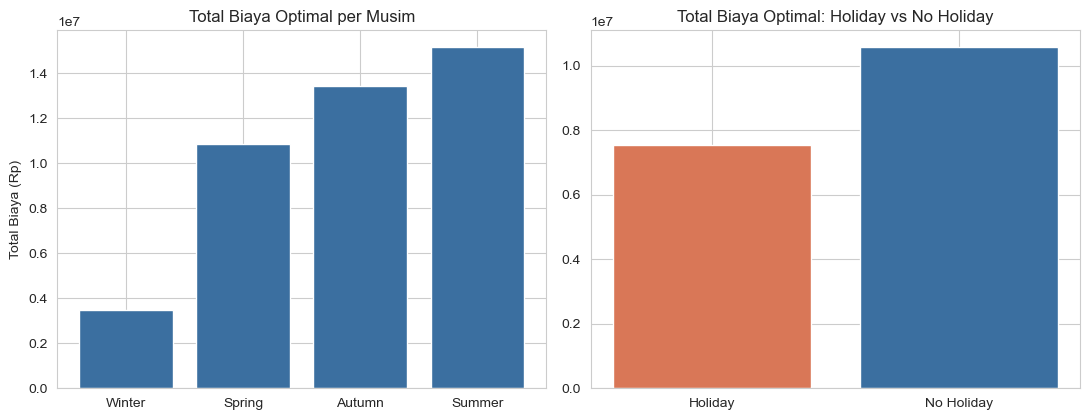

In [30]:
#---------------------------------------------------
# 12.3 Visualisasi Perbandingan Biaya Antar Skenario
#---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

season_order = ['Winter', 'Spring', 'Autumn', 'Summer']
axes[0].bar(season_order, [season_results[s]['total_cost'] for s in season_order], color='#3b6fa0')
axes[0].set_title('Total Biaya Optimal per Musim')
axes[0].set_ylabel('Total Biaya (Rp)')

axes[1].bar(holiday_results.keys(), [holiday_results[h]['total_cost'] for h in holiday_results],
            color=['#d97757', '#3b6fa0'])
axes[1].set_title('Total Biaya Optimal: Holiday vs No Holiday')

plt.tight_layout()
plt.show()

Hasil re-optimisasi menunjukkan rentang biaya yang sangat lebar antarmusim: Winter hanya membutuhkan Rp3.475.000, sementara Summer melonjak ke Rp15.150.000, sekitar 4,4 kali lipat. Jumlah staf reguler naik dari 13 orang di Winter menjadi 48 orang di Summer, dan jam staf tambahan melonjak dari 28 menjadi 160 jam. Pola serupa terlihat pada Holiday (Rp7.562.500) dibanding No Holiday (Rp10.575.000), meski selisihnya jauh lebih kecil dibanding antarmusim. Temuan ini menunjukkan bahwa perencanaan staf yang statis sepanjang tahun berisiko sangat understaffed di musim panas dan overstaffed di musim dingin jika dipaksakan memakai satu rencana yang sama.

## **`[13]` Sensitivity Analysis: Parametrik (Tornado Chart)**

Setiap parameter Asumsi (kapasitas per staf, demand sintetis, multiplier staf tambahan, batas staf per shift) diperturbasi satu per satu sebesar -20% dan +20% dari nilai baseline, lalu dampaknya terhadap total biaya direkam. Pendekatan one-at-a-time ini dipilih karena tetap valid untuk model MIP, berbeda dari shadow price yang hanya valid untuk LP.

In [31]:
# ==================================================
# 13. SENSITIVITY ANALYSIS - PARAMETRIK (TORNADO CHART)
# ==================================================
#---------------------------------------------------
# 13.1 Sweep One-at-a-Time
#---------------------------------------------------
BASE_COST = res_baseline['total_cost']

param_specs = [
    ('Demand (skenario sintetis naik/turun)', lambda f: solve_model(baseline_demand * f)),
    ('Kapasitas per staf', lambda f: solve_model(baseline_demand, capacity=CAPACITY_PER_WORKER * f)),
    ('Multiplier biaya staf tambahan', lambda f: solve_model(baseline_demand, premium_mult=PREMIUM_MULTIPLIER * f)),
    ('Batas staf reguler per shift', lambda f: solve_model(baseline_demand,
        max_per_shift=int(round(MAX_WORKERS_PER_SHIFT * f)))),
]

tornado_rows = []
for label, fn in param_specs:
    cost_low = fn(0.8)['total_cost']
    cost_high = fn(1.2)['total_cost']
    tornado_rows.append({
        'parameter': label,
        'delta_low_pct': (cost_low - BASE_COST) / BASE_COST * 100,
        'delta_high_pct': (cost_high - BASE_COST) / BASE_COST * 100,
    })

tornado_df = pd.DataFrame(tornado_rows)
tornado_df['impact_range'] = (tornado_df['delta_high_pct'] - tornado_df['delta_low_pct']).abs()
tornado_df = tornado_df.sort_values('impact_range').reset_index(drop=True)
print(tornado_df)

                               parameter  delta_low_pct  delta_high_pct  \
0           Batas staf reguler per shift           1.90           -0.24   
1         Multiplier biaya staf tambahan          -6.54            5.26   
2  Demand (skenario sintetis naik/turun)         -20.33           20.81   
3                     Kapasitas per staf          25.33          -16.53   

   impact_range  
0          2.14  
1         11.80  
2         41.14  
3         41.85  


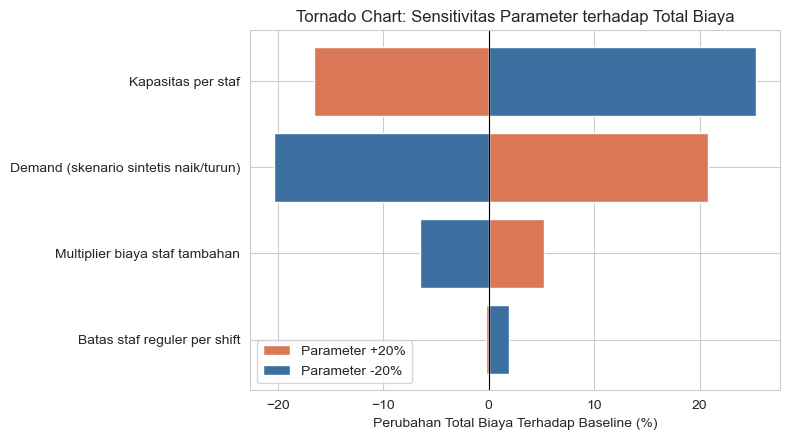

In [32]:
#---------------------------------------------------
# 13.2 Visualisasi Tornado Chart
#---------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = range(len(tornado_df))
ax.barh(y_pos, tornado_df['delta_high_pct'], color='#d97757', label='Parameter +20%')
ax.barh(y_pos, tornado_df['delta_low_pct'], color='#3b6fa0', label='Parameter -20%')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(tornado_df['parameter'])
ax.set_xlabel('Perubahan Total Biaya Terhadap Baseline (%)')
ax.set_title('Tornado Chart: Sensitivitas Parameter terhadap Total Biaya')
ax.legend()
plt.tight_layout()
plt.show()

Tornado chart menyimpulkan urutan sensitivitas yang cukup mengejutkan. **Kapasitas per staf** menjadi parameter paling sensitif, dengan dampak hingga +25,3% pada total biaya jika kapasitasnya diturunkan 20%, sedikit melampaui dampak skenario demand naik 20% (+20,8%). Sementara itu, perubahan **multiplier biaya staf tambahan** sebesar 20% hanya menggerakkan total biaya sekitar 5-7%, dan **batas staf per shift** praktis tidak berpengaruh (di bawah 2%). Urutan ini penting karena jika ada keterbatasan waktu untuk memvalidasi parameter Asumsi dengan data riil, validasi angka kapasitas per staf seharusnya jadi prioritas pertama, bukan tarif staf tambahan yang sering jadi sorotan utama dalam diskusi biaya tenaga kerja.

## **`[14]` Trade-off Frontier: Biaya vs Service Level**

Target service level (porsi kebutuhan staf yang wajib terpenuhi) divariasikan dari 70% hingga 100%, lalu model diselesaikan ulang pada tiap level untuk melihat kurva trade-off antara penghematan biaya dan penurunan kualitas layanan.

In [33]:
# ==================================================
# 14. TRADE-OFF FRONTIER BIAYA VS SERVICE LEVEL
# ==================================================
#---------------------------------------------------
# 14.1 Sweep Service Level
#---------------------------------------------------
service_levels = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00]
frontier_rows = []
for lvl in service_levels:
    r = solve_model(baseline_demand, service_level=lvl)
    frontier_rows.append({
        'service_level': lvl,
        'total_cost': r['total_cost'],
        'regular_cost': r['regular_cost'],
        'cost_staf_tambahan': r['cost_staf_tambahan'],
        'staf_reguler': sum(r['x'].values()),
    })
frontier_df = pd.DataFrame(frontier_rows)
print(frontier_df)

   service_level    total_cost  regular_cost  cost_staf_tambahan  staf_reguler
0           0.70  7,662,500.00  5,975,000.00        1,687,500.00         32.00
1           0.75  8,050,000.00  6,325,000.00        1,725,000.00         34.00
2           0.80  8,637,500.00  6,500,000.00        2,137,500.00         35.00
3           0.85  9,200,000.00  7,100,000.00        2,100,000.00         38.00
4           0.90  9,700,000.00  7,450,000.00        2,250,000.00         40.00
5           0.95 10,250,000.00  7,625,000.00        2,625,000.00         41.00
6           1.00 10,512,500.00  7,625,000.00        2,887,500.00         41.00


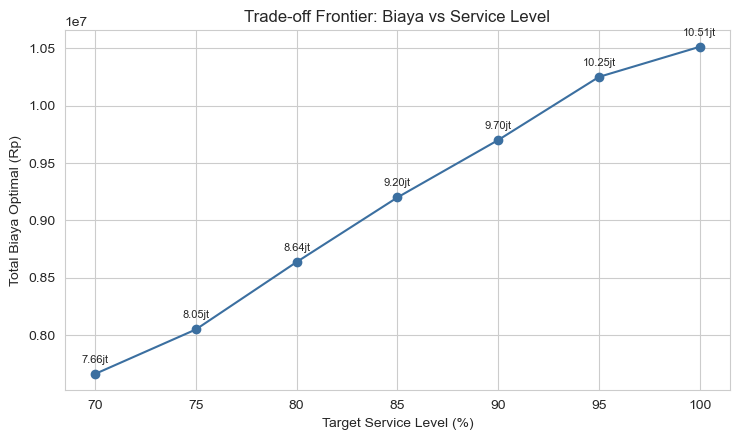

In [34]:
#---------------------------------------------------
# 14.2 Visualisasi Trade-off Frontier
#---------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(frontier_df['service_level'] * 100, frontier_df['total_cost'], marker='o', color='#3b6fa0')
ax.set_xlabel('Target Service Level (%)')
ax.set_ylabel('Total Biaya Optimal (Rp)')
ax.set_title('Trade-off Frontier: Biaya vs Service Level')
for _, row in frontier_df.iterrows():
    ax.annotate(f"{row['total_cost']/1e6:.2f}jt", (row['service_level']*100, row['total_cost']),
                textcoords='offset points', xytext=(0, 8), fontsize=8, ha='center')
plt.tight_layout()
plt.show()

Kurva ini naik secara halus dan konsisten, dari Rp7.662.500 pada service level 70% hingga Rp10.512.500 pada 100%. Artinya menurunkan target layanan dari penuh ke 70% berpotensi menghemat sekitar 27% biaya tenaga kerja. Yang perlu digarisbawahi, penghematan ini didapat dengan konsekuensi langsung berupa kekurangan staf pada jam-jam tertentu. Kurva semacam ini cocok dipakai sebagai alat diskusi dengan pemangku kebijakan operasional untuk menentukan titik service level mana yang sepadan dengan penghematannya, bukan sekadar memilih biaya termurah.

## **`[15]` Diagnostic Tambahan: Linear Programming (LP) Relaxation dan Shadow Price**

Shadow price (dual value) secara teori hanya valid untuk variabel kontinu (LP), bukan untuk variabel integer (MIP). Bagian ini menyelesaikan ulang model yang sama dengan variabel direlaksasi menjadi kontinu, khusus untuk menarik shadow price sebagai diagnostic tambahan, bukan pengganti solusi MIP pada Section 11.

In [35]:
# ==================================================
# 15. DIAGNOSTIC TAMBAHAN: LP RELAXATION DAN SHADOW PRICE
# ==================================================
#---------------------------------------------------
# 15.1 Solve LP Relaxation
#---------------------------------------------------
res_lp = solve_model(baseline_demand, integer=False)
print('Status LP relaxation :', res_lp['status'])
print('Total biaya LP        : Rp', f"{res_lp['total_cost']:,.2f}")
print('Total biaya MIP       : Rp', f"{res_baseline['total_cost']:,.2f}")

Status LP relaxation : Optimal
Total biaya LP        : Rp 10,512,500.00
Total biaya MIP       : Rp 10,512,500.00


Total biaya hasil LP relaxation persis sama dengan hasil MIP (Rp10.512.500), menandakan tidak ada integrality gap pada kasus ini, solusi MIP yang dipakai sejak Section 11 memang sudah optimal tanpa perlu rounding heuristic apa pun. Ini mengonfirmasi solusi baseline aman dipakai sebagai acuan, sekaligus menjadi alasan kuat untuk melanjutkan ke ekstraksi shadow price pada LP relaxation ini.

In [36]:
#---------------------------------------------------
# 15.2 Ekstraksi Shadow Price per Jam
#---------------------------------------------------
prob_lp = res_lp['prob']
shadow_prices = []
for h, cname in res_lp['coverage_constraints'].items():
    con = prob_lp.constraints[cname]
    shadow_prices.append({'hour': h, 'required': res_lp['R'][h], 'shadow_price': con.pi})
shadow_df = pd.DataFrame(shadow_prices)
print(shadow_df)

print('\nDual value dan slack pada constraint batas kapasitas tiap shift:')
for s in SHIFTS:
    con_cap = prob_lp.constraints[f'maxcap_{s}']
    print(f"{s:6s} | x={res_lp['x'][s]:.1f} | dual={con_cap.pi} | slack={con_cap.slack}")

    hour  required  shadow_price
0      0        12     37,500.00
1      1         9     37,500.00
2      2         7     37,500.00
3      3         5          0.00
4      4         3          0.00
5      5         3          0.00
6      6         6     25,000.00
7      7        13     37,500.00
8      8        22     37,500.00
9      9        14     37,500.00
10    10        11          0.00
11    11        13          0.00
12    12        15     25,000.00
13    13        16     37,500.00
14    14        16     37,500.00
15    15        18     37,500.00
16    16        20     37,500.00
17    17        24     37,500.00
18    18        32     37,500.00
19    19        25     37,500.00
20    20        23     37,500.00
21    21        22     37,500.00
22    22        20          0.00
23    23        14          0.00

Dual value dan slack pada constraint batas kapasitas tiap shift:
Pagi   | x=6.0 | dual=0.0 | slack=14.0
Siang  | x=15.0 | dual=0.0 | slack=5.0
Malam  | x=20.0 | dual=-12500.0

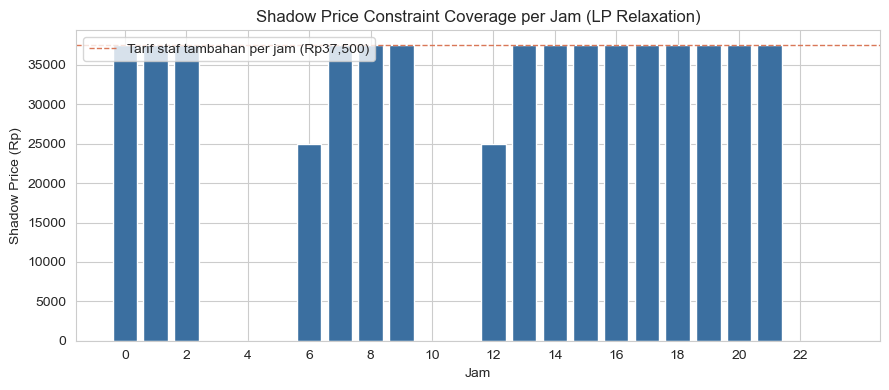

In [37]:
#---------------------------------------------------
# 15.3 Visualisasi Shadow Price per Jam
#---------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(shadow_df['hour'], shadow_df['shadow_price'], color='#3b6fa0')
ax.axhline(COST_STAF_TAMBAHAN_PER_HOUR, color='#d97757', linestyle='--', linewidth=1,
           label=f'Tarif staf tambahan per jam (Rp{COST_STAF_TAMBAHAN_PER_HOUR:,.0f})')
ax.set_xlabel('Jam')
ax.set_ylabel('Shadow Price (Rp)')
ax.set_title('Shadow Price Constraint Coverage per Jam (LP Relaxation)')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

Pada sebagian besar jam yang binding, shadow price persis sama dengan tarif staf tambahan per jam (Rp37.500), masuk akal karena unit tambahan kebutuhan staf di jam tersebut secara marginal ditutup lewat satu staf tambahan. Ada juga dua jam dengan shadow price lebih rendah, yaitu jam 06.00 dan 12.00 (Rp25.000), serta beberapa jam dengan shadow price nol karena coverage-nya memang masih longgar (jam 3, 4, 5, 10, 11, 23). Bagian yang perlu diperhatikan ada pada jam 22.00: shadow price-nya nol meski constraint tersebut binding, karena kebutuhan di jam itu (20 orang) persis sama dengan batas kapasitas shift Malam, indikasi **degenerasi** pada solusi dual di titik tersebut. Sebaliknya, dual value pada batas kapasitas shift Malam sendiri justru bersih bernilai -Rp12.500, dan berpotensi menurunkan total biaya sekitar Rp12.500, karena sebagian staf tambahan yang lebih mahal bisa digantikan.

In [38]:
import os

os.makedirs("docs/img", exist_ok=True)

names = [
    '01_demand_distribution',
    '02_hourly_demand_profile',
    '03_seasonal_demand_profile',
    '04_holiday_vs_noholiday',
    '05_heatmap_demand_season',
    '06_staffing_baseline',
    '07_cost_comparison_scenarios',
    '08_tornado_chart',
    '09_tradeoff_frontier',
    '10_shadow_price_per_hour'
]

for fig, name in zip(saved_figures, names):
    fig.savefig(
        f"docs/img/{name}.png",
        dpi=150,
        bbox_inches="tight"
    )

## **`[16]` Kesimpulan**

Model MIP shift scheduling ini berhasil diselesaikan dengan status Optimal di seluruh skenario yang diuji. Pada profil demand baseline, solusi optimal menghasilkan total biaya Rp10.512.500 per hari representative, terdiri dari biaya reguler Rp7.625.000 dan biaya staf tambahan Rp2.887.500 (sekitar 27,5% dari total biaya). Dari 41 staf reguler yang dialokasikan, sebaran 6 Pagi, 15 Siang, dan 20 Malam ini cukup unik. Shift Malam yang durasinya paling pendek (7 jam, dibanding Pagi 10 jam) justru menyerap staf reguler paling banyak, karena di sanalah jam puncak demand tertinggi terjadi, terutama jam 18.00 yang sendirian membutuhkan 32 orang.

Re-optimisasi pada profil demand per musim menunjukkan rentang biaya yang sangat lebar, dari Rp3.475.000 pada Winter hingga Rp15.150.000 pada Summer, rasio sekitar 4,4 kali, konsisten dengan perbedaan demand riil sekitar 4,6 kali antara kedua musim tersebut. Status holiday juga berpengaruh meski lebih moderat (Rp7.562.500 berbanding Rp10.575.000).

Tornado chart parametrik mengungkap bahwa asumsi kapasitas per staf adalah parameter paling sensitif terhadap total biaya, dengan dampak hingga +25,3% jika diturunkan 20%, melampaui dampak kenaikan demand 20% (+20,8%) maupun kenaikan tarif staf tambahan 20% (+5,3%). Batas staf per shift, sebaliknya, hampir tidak berpengaruh (di bawah 2%). Urutan ini penting karena berlawanan dengan intuisi umum yang biasanya menyoroti tarif staf tambahan sebagai isu utama biaya tenaga kerja.

Staf tambahan paling besar terjadi tepat di dua titik puncak bimodal yang sudah teridentifikasi sejak EDA, yaitu jam 08.00 (16 orang) dan jam 18.00 (12 orang), bukan tersebar di jam-jam transisi antar-shift. Shift Malam yang menanggung beban puncak sore menyentuh batas kapasitas 20 orang, dan shadow price pada batas kapasitas tersebut bernilai bersih -Rp12.500, yang berarti menambah kuota staf di shift itu akan menurunkan biaya.

## **`[17]` Catatan & Temuan Utama**

**`a)` Catatan:**
1.   Profil demand representative day dihitung dari rata-rata historis per kelompok (musim, holiday), bukan demand satu hari aktual, sehingga nilai kebutuhan staf di tiap jam sebaiknya dibaca sebagai estimasi rata-rata, bukan angka pasti harian.

**`b)` Temuan Utama:**
1.   Biaya optimal sangat sensitif terhadap musim, dari Rp3.475.000 (Winter) hingga Rp15.150.000 (Summer), sekitar 4,4 kali lipat, jauh melebihi sensitivitas terhadap parameter Asumsi mana pun.
2.   Menurunkan target service level dari 100% ke 70% dapat menghemat sekitar 27% biaya, namun konsekuensinya kebutuhan staf pada sejumlah jam dibiarkan tidak terpenuhi penuh, bukan efisiensi tanpa risiko.
3.   Batas kapasitas staf reguler per shift (maks staf = 20) terbukti mengikat dan menahan sekitar Rp25.000 potensi penghematan per hari. Sebelum mengusulkan pelonggaran batas ini secara operasional, perlu dicek apakah ada alasan non-finansial di baliknya (anggaran headcount, kapasitas ruang kerja, atau regulasi ketenagakerjaan).

---

<p align="right">
<i>Ahmad Kenzy Farzaq • 2026</i>
</p>